# Demo for path context retriever

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from path_cont_retr import PathContextRetrieval

Decision NOTE: due to fu-ref from 2023 from Ilya We need to set this file from 2021 '/lustre/acslab/shared/LLM_stuff/subgraph_retrieval/medline_cooc_graphs/2021_11_22_cooc_graph_titles_mcl.pkl' to retrieve path

In [2]:
path_cont_retr_obj = PathContextRetrieval(
    config_path='/work/acslab/shared/llm_expl_shared_data/hgcr_config_081924_shared.json'
)

Init ranker model...
Init node embeddings...
Init co-occur graph...
graph-tool network constructed!
Init context embeddings...
Using MedCPT


Constructing PMID lookup index: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:24<00:00,  1.58it/s]


In [3]:
path_cont_retr_obj.mcg_obj.pmid_to_ts_dict['20377462']

'2010'

In [4]:
path_cont_retr_obj.mcg_obj.pmid_to_ts_dict['22293089']
# path_cont_retr_obj.mcg_obj.pmid_to_ts_dict['21187224']
# path_cont_retr_obj.mcg_obj.pmid_to_ts_dict['34164801']

'2012'

In [5]:
pwd

'/work/acslab/users/svalipou/HGCR'

## 2. Verify 3rd round result from VIAV:

## Function to read .txt file and have it as df for pkl format from row data:

In [6]:
import pandas as pd
import re
file_path = '/work/acslab/users/svalipou/HGCR/viva_result/3rd_txt/responses_with_links_pubmed_viav_3.txt'

In [7]:
with open(file_path, 'r') as file:
    file_content = file.read()

entries = file_content.strip().split('================================================================================')
questions, prompts, responses, context_pmids, subj_names, obj_names = [], [], [], [], [], []

for entry in entries:
    question_match = re.search(r'Question \d+:', entry)
    prompt_match = re.search(r'Based on your information, please describe how an indirect relationship between (.*?) and (.*?) might exist\.', entry, re.DOTALL)
    response_match = re.search(r'Response:\n(.*?)(?:References:|$)', entry, re.DOTALL)
    references_match = re.findall(r'https://pubmed.ncbi.nlm.nih.gov/(\d+)/', entry)

    if question_match and prompt_match and response_match:
        questions.append(question_match.group(0).strip())
        prompts.append(prompt_match.group(0).strip())
        subj_names.append(prompt_match.group(1).strip())
        obj_names.append(prompt_match.group(2).strip())
        responses.append(response_match.group(1).strip())
        context_pmids.append(references_match)

df = pd.DataFrame({
    'subj_name': subj_names,
    'obj_name': obj_names,
    'prompt': prompts,
    'Response': responses,
    'context_pmids': context_pmids
})

df

,subj_name,obj_name,prompt,Response,context_pmids
0,acetaminophen,CTSL gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[20377462, 22293089, 33180786, 6697867, 810715..."
1,acetaminophen,EIF2AK4 gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[22293089, 20377462, 33180786, 35430857, 66978..."
2,adenosine,pheniramine,"Based on your information, please describe how...","In the context of the provided papers, an indi...","[22293089, 33180786, 31256712, 8107150, 696096..."
3,ethanol,ATG4B gene,"Based on your information, please describe how...",The indirect relationship between ethanol and ...,"[20377462, 22293089, 32787124, 8843485, 331807..."
4,alfentanil,remimazolam,"Based on your information, please describe how...",Alfentanil and remimazolam may have an indirec...,"[7946858, 7905796, 8242265, 9723968, 17439409,..."
...,...,...,...,...,...
237,gambogenic acid,"ACTA2 protein, human","Based on your information, please describe how...",Gambogenic acid (GEA) has been studied for its...,"[37193064, 27025602, 25087947, 23163528, 33180..."
238,canakinumab,zanubrutinib,"Based on your information, please describe how...","Canakinumab, an interleukin-1β inhibitor, has ...","[35430857, 33180786, 30832770, 33266517, 81071..."
239,entrectinib,dabrafenib,"Based on your information, please describe how...",Entrectinib and dabrafenib are both medication...,"[35406565, 35430857, 33180786, 8107150, 332665..."
240,larotrectinib,dabrafenib,"Based on your information, please describe how...",Based on the information provided in the paper...,"[35406565, 37533946, 33180786, 33622165, 32452..."


In [4]:
df=pd.read_pickle('df_viav_3.pkl')
df

,subj_name,obj_name,prompt,Response,context_pmids
0,acetaminophen,CTSL gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[20377462, 22293089, 33180786, 6697867, 810715..."
1,acetaminophen,EIF2AK4 gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[22293089, 20377462, 33180786, 35430857, 66978..."
2,adenosine,pheniramine,"Based on your information, please describe how...","In the context of the provided papers, an indi...","[22293089, 33180786, 31256712, 8107150, 696096..."
3,ethanol,ATG4B gene,"Based on your information, please describe how...",The indirect relationship between ethanol and ...,"[20377462, 22293089, 32787124, 8843485, 331807..."
4,alfentanil,remimazolam,"Based on your information, please describe how...",Alfentanil and remimazolam may have an indirec...,"[7946858, 7905796, 8242265, 9723968, 17439409,..."
...,...,...,...,...,...
237,gambogenic acid,"ACTA2 protein, human","Based on your information, please describe how...",Gambogenic acid (GEA) has been studied for its...,"[37193064, 27025602, 25087947, 23163528, 33180..."
238,canakinumab,zanubrutinib,"Based on your information, please describe how...","Canakinumab, an interleukin-1β inhibitor, has ...","[35430857, 33180786, 30832770, 33266517, 81071..."
239,entrectinib,dabrafenib,"Based on your information, please describe how...",Entrectinib and dabrafenib are both medication...,"[35406565, 35430857, 33180786, 8107150, 332665..."
240,larotrectinib,dabrafenib,"Based on your information, please describe how...",Based on the information provided in the paper...,"[35406565, 37533946, 33180786, 33622165, 32452..."


### Apply function to get the most updatest publication date from .json file.

In [5]:
with open("/work/acslab/users/svalipou/HGCR/viva_result/pmid_to_yr_010725_dict.json", "r") as f:
    pmid_to_date = json.load(f)
def get_publication_dates(pmid_list):
    return [pmid_to_date.get(str(pmid), "Unknown") for pmid in pmid_list]
df['context_pmids_pub_date_updated'] = df['context_pmids'].apply(get_publication_dates)

df.to_pickle('most_updated_dataframe_with_pub_dates_3rd_times.pkl')
df

,subj_name,obj_name,prompt,Response,context_pmids,context_pmids_pub_date_updated
0,acetaminophen,CTSL gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[20377462, 22293089, 33180786, 6697867, 810715...","[2010, 2012, 2020, 1984, 1993, 1997, 2014, 202..."
1,acetaminophen,EIF2AK4 gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[22293089, 20377462, 33180786, 35430857, 66978...","[2012, 2010, 2020, 2022, 1984, 1993, 1997, 201..."
2,adenosine,pheniramine,"Based on your information, please describe how...","In the context of the provided papers, an indi...","[22293089, 33180786, 31256712, 8107150, 696096...","[2012, 2020, 2019, 1993, 1982, 2014, 2010, 199..."
3,ethanol,ATG4B gene,"Based on your information, please describe how...",The indirect relationship between ethanol and ...,"[20377462, 22293089, 32787124, 8843485, 331807...","[2010, 2012, 2020, 1996, 2020, 1994, 2022, 199..."
4,alfentanil,remimazolam,"Based on your information, please describe how...",Alfentanil and remimazolam may have an indirec...,"[7946858, 7905796, 8242265, 9723968, 17439409,...","[1994, 1993, 1993, 1998, 2007, 2020, 1988, 198..."
...,...,...,...,...,...,...
237,gambogenic acid,"ACTA2 protein, human","Based on your information, please describe how...",Gambogenic acid (GEA) has been studied for its...,"[37193064, 27025602, 25087947, 23163528, 33180...","[2022, 2015, 2014, 2012, 2020, 2008, 1996, 202..."
238,canakinumab,zanubrutinib,"Based on your information, please describe how...","Canakinumab, an interleukin-1β inhibitor, has ...","[35430857, 33180786, 30832770, 33266517, 81071...","[2022, 2020, 2018, 2020, 1993, 2019, 2014, 201..."
239,entrectinib,dabrafenib,"Based on your information, please describe how...",Entrectinib and dabrafenib are both medication...,"[35406565, 35430857, 33180786, 8107150, 332665...","[2022, 2022, 2020, 1993, 2020, 2014, 2010, 202..."
240,larotrectinib,dabrafenib,"Based on your information, please describe how...",Based on the information provided in the paper...,"[35406565, 37533946, 33180786, 33622165, 32452...","[2022, 2023, 2020, 2021, 2019, 1993, 2023, 201..."


In [6]:
def has_date_greater_than_2021(dates_list):
    return any(int(date) > 2021 for date in dates_list)
filtered_df = df[df['context_pmids_pub_date_updated'].apply(has_date_greater_than_2021)]
filtered_df

,subj_name,obj_name,prompt,Response,context_pmids,context_pmids_pub_date_updated
0,acetaminophen,CTSL gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[20377462, 22293089, 33180786, 6697867, 810715...","[2010, 2012, 2020, 1984, 1993, 1997, 2014, 202..."
1,acetaminophen,EIF2AK4 gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[22293089, 20377462, 33180786, 35430857, 66978...","[2012, 2010, 2020, 2022, 1984, 1993, 1997, 201..."
2,adenosine,pheniramine,"Based on your information, please describe how...","In the context of the provided papers, an indi...","[22293089, 33180786, 31256712, 8107150, 696096...","[2012, 2020, 2019, 1993, 1982, 2014, 2010, 199..."
3,ethanol,ATG4B gene,"Based on your information, please describe how...",The indirect relationship between ethanol and ...,"[20377462, 22293089, 32787124, 8843485, 331807...","[2010, 2012, 2020, 1996, 2020, 1994, 2022, 199..."
5,F3 wt Allele,Alzheimer's Disease,"Based on your information, please describe how...",The papers suggest that there may be an indire...,"[27357286, 18086003, 25426068, 8871952, 193871...","[2016, 2007, 2014, 1996, 2009, 2014, 2022, 201..."
...,...,...,...,...,...,...
237,gambogenic acid,"ACTA2 protein, human","Based on your information, please describe how...",Gambogenic acid (GEA) has been studied for its...,"[37193064, 27025602, 25087947, 23163528, 33180...","[2022, 2015, 2014, 2012, 2020, 2008, 1996, 202..."
238,canakinumab,zanubrutinib,"Based on your information, please describe how...","Canakinumab, an interleukin-1β inhibitor, has ...","[35430857, 33180786, 30832770, 33266517, 81071...","[2022, 2020, 2018, 2020, 1993, 2019, 2014, 201..."
239,entrectinib,dabrafenib,"Based on your information, please describe how...",Entrectinib and dabrafenib are both medication...,"[35406565, 35430857, 33180786, 8107150, 332665...","[2022, 2022, 2020, 1993, 2020, 2014, 2010, 202..."
240,larotrectinib,dabrafenib,"Based on your information, please describe how...",Based on the information provided in the paper...,"[35406565, 37533946, 33180786, 33622165, 32452...","[2022, 2023, 2020, 2021, 2019, 1993, 2023, 201..."


In [7]:
filtered_df.to_pickle('filtered_viav_df_3rd_2022_136_rows.pkl')

In [12]:
def count_dates_greater_than_2021(dates_list):
    return sum(int(date) > 2021 for date in dates_list)

df['count_publication_date_higher'] = df['context_pmids_pub_date_updated'].apply(count_dates_greater_than_2021)
filtered_df = df[df['count_publication_date_higher'] > 0]
filtered_df

,subj_name,obj_name,prompt,Response,context_pmids,context_pmids_pub_date_updated,count_publication_date_higher
0,acetaminophen,CTSL gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[20377462, 22293089, 33180786, 6697867, 810715...","[2010, 2012, 2020, 1984, 1993, 1997, 2014, 202...",1
1,acetaminophen,EIF2AK4 gene,"Based on your information, please describe how...",An indirect relationship between acetaminophen...,"[22293089, 20377462, 33180786, 35430857, 66978...","[2012, 2010, 2020, 2022, 1984, 1993, 1997, 201...",1
2,adenosine,pheniramine,"Based on your information, please describe how...","In the context of the provided papers, an indi...","[22293089, 33180786, 31256712, 8107150, 696096...","[2012, 2020, 2019, 1993, 1982, 2014, 2010, 199...",1
3,ethanol,ATG4B gene,"Based on your information, please describe how...",The indirect relationship between ethanol and ...,"[20377462, 22293089, 32787124, 8843485, 331807...","[2010, 2012, 2020, 1996, 2020, 1994, 2022, 199...",1
5,F3 wt Allele,Alzheimer's Disease,"Based on your information, please describe how...",The papers suggest that there may be an indire...,"[27357286, 18086003, 25426068, 8871952, 193871...","[2016, 2007, 2014, 1996, 2009, 2014, 2022, 201...",1
...,...,...,...,...,...,...,...
237,gambogenic acid,"ACTA2 protein, human","Based on your information, please describe how...",Gambogenic acid (GEA) has been studied for its...,"[37193064, 27025602, 25087947, 23163528, 33180...","[2022, 2015, 2014, 2012, 2020, 2008, 1996, 202...",2
238,canakinumab,zanubrutinib,"Based on your information, please describe how...","Canakinumab, an interleukin-1β inhibitor, has ...","[35430857, 33180786, 30832770, 33266517, 81071...","[2022, 2020, 2018, 2020, 1993, 2019, 2014, 201...",1
239,entrectinib,dabrafenib,"Based on your information, please describe how...",Entrectinib and dabrafenib are both medication...,"[35406565, 35430857, 33180786, 8107150, 332665...","[2022, 2022, 2020, 1993, 2020, 2014, 2010, 202...",2
240,larotrectinib,dabrafenib,"Based on your information, please describe how...",Based on the information provided in the paper...,"[35406565, 37533946, 33180786, 33622165, 32452...","[2022, 2023, 2020, 2021, 2019, 1993, 2023, 201...",4


In [1]:
filtered_df

NameError: name 'filtered_df' is not defined

In [17]:
def count_dates_greater_than_2021(dates_list):
    return sum(int(date) > 2021 for date in dates_list)

df['count_publication_date_higher'] = df['context_pmids_pub_date_updated'].apply(count_dates_greater_than_2021)
filtered_df_not_include_2021 = df[df['count_publication_date_higher'] == 0]
filtered_df_not_include_2021

,subj_name,obj_name,prompt,Response,context_pmids,context_pmids_pub_date_updated,count_publication_date_higher,response_length
4,alfentanil,remimazolam,"Based on your information, please describe how...",Alfentanil and remimazolam may have an indirec...,"[7946858, 7905796, 8242265, 9723968, 17439409,...","[1994, 1993, 1993, 1998, 2007, 2020, 1988, 198...",0,2226
11,Bipolar Disorder,Thyrotoxic periodic paralysis,"Based on your information, please describe how...",The papers provide insights into the potential...,"[2155749, 23291679, 27788314, 8403805, 1189387...","[1990, 2013, 2015, 1993, 2002, 1998, 2000, 199...",0,2794
14,ceftriaxone,selenium,"Based on your information, please describe how...","Ceftriaxone, a commonly used antibiotic, has b...","[1980438, 33180786, 7719737, 23163528, 2229308...","[1990, 2020, 1994, 2012, 2012, 1986, 2010, 198...",0,2763
15,"TCF7L2 protein, human",Cerebral Infarction,"Based on your information, please describe how...","The TCF7L2 protein, also known as TCF4, is a t...","[10079969, 31709500, 7835145, 1202432, 2165372...","[1999, 2019, 1994, 1975, 2011, 1982, 2013, 201...",0,2012
16,formoterol fumarate,"Bronchitis, Chronic","Based on your information, please describe how...","Formoterol fumarate, a potent beta 2-adrenocep...","[7170790, 8568542, 10464898, 19428233, 945891,...","[1982, 1995, 1999, 2008, 1976, 1986, 2002, 199...",0,2225
...,...,...,...,...,...,...,...,...
222,RAC1 gene,PARK7 gene,"Based on your information, please describe how...",The indirect relationship between the RAC1 gen...,"[20377462, 21187224, 34781497, 34561450, 22293...","[2010, 2010, 2020, 2020, 2012, 2002, 2020, 200...",0,2438
223,SOD1 gene,SMCR8 gene,"Based on your information, please describe how...",The papers provide insights into inferring bio...,"[20377462, 21187224, 26105819, 33004804, 10405...","[2010, 2010, 2014, 2019, 1999, 2020, 2009, 1997]",0,2574
226,TWIST1 gene,"Receptor Tyrosine-Protein Kinase ErbB-4, human","Based on your information, please describe how...",The TWIST1 gene and Receptor Tyrosine-Protein ...,[],[],0,2380
228,XPO1 gene,YTHDF1 gene,"Based on your information, please describe how...","The XPO1 gene, known for its role in nuclear e...","[20377462, 21187224, 24911659, 34781497, 34081...","[2010, 2010, 2014, 2020, 2021, 2012, 2002, 200...",0,2226


In [18]:
filtered_df_not_include_2021.to_pickle('viav_3_exe_106_rows.pkl')

In [13]:
len(filtered_df)

136

/tmp/job_29467057/step_0.0/ipykernel_171995/642248093.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_not_include_2021['response_length'] = filtered_df_not_include_2021['Response'].apply(len)


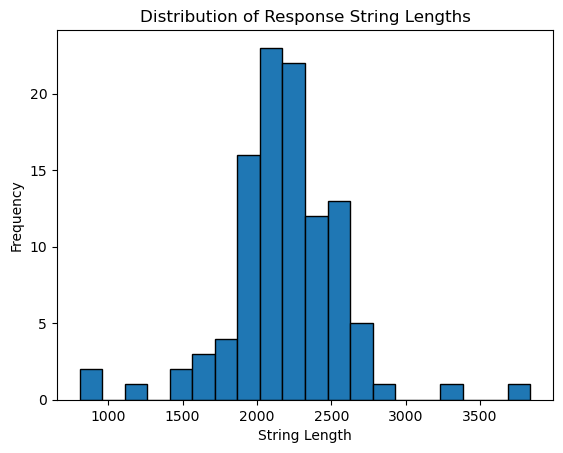

count     106.000000
mean     2185.707547
std       390.676409
min       807.000000
25%      2013.500000
50%      2179.500000
75%      2389.750000
max      3839.000000
Name: response_length, dtype: float64

In [19]:


filtered_df_not_include_2021['response_length'] = filtered_df_not_include_2021['Response'].apply(len)
response_length_stats = filtered_df_not_include_2021['response_length'].describe()

# Step 3: Plot the distribution of string lengths
plt.hist(filtered_df_not_include_2021['response_length'], bins=20, edgecolor='black')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.title('Distribution of Response String Lengths')
plt.show()

# Displaying the summary statistics for the user
response_length_stats

In [2]:
df = pd.read_pickle('viav_3_exe_106_rows.pkl')
df

,subj_name,obj_name,prompt,Response,context_pmids,context_pmids_pub_date_updated,count_publication_date_higher,response_length
4,alfentanil,remimazolam,"Based on your information, please describe how...",Alfentanil and remimazolam may have an indirec...,"[7946858, 7905796, 8242265, 9723968, 17439409,...","[1994, 1993, 1993, 1998, 2007, 2020, 1988, 198...",0,2226
11,Bipolar Disorder,Thyrotoxic periodic paralysis,"Based on your information, please describe how...",The papers provide insights into the potential...,"[2155749, 23291679, 27788314, 8403805, 1189387...","[1990, 2013, 2015, 1993, 2002, 1998, 2000, 199...",0,2794
14,ceftriaxone,selenium,"Based on your information, please describe how...","Ceftriaxone, a commonly used antibiotic, has b...","[1980438, 33180786, 7719737, 23163528, 2229308...","[1990, 2020, 1994, 2012, 2012, 1986, 2010, 198...",0,2763
15,"TCF7L2 protein, human",Cerebral Infarction,"Based on your information, please describe how...","The TCF7L2 protein, also known as TCF4, is a t...","[10079969, 31709500, 7835145, 1202432, 2165372...","[1999, 2019, 1994, 1975, 2011, 1982, 2013, 201...",0,2012
16,formoterol fumarate,"Bronchitis, Chronic","Based on your information, please describe how...","Formoterol fumarate, a potent beta 2-adrenocep...","[7170790, 8568542, 10464898, 19428233, 945891,...","[1982, 1995, 1999, 2008, 1976, 1986, 2002, 199...",0,2225
...,...,...,...,...,...,...,...,...
222,RAC1 gene,PARK7 gene,"Based on your information, please describe how...",The indirect relationship between the RAC1 gen...,"[20377462, 21187224, 34781497, 34561450, 22293...","[2010, 2010, 2020, 2020, 2012, 2002, 2020, 200...",0,2438
223,SOD1 gene,SMCR8 gene,"Based on your information, please describe how...",The papers provide insights into inferring bio...,"[20377462, 21187224, 26105819, 33004804, 10405...","[2010, 2010, 2014, 2019, 1999, 2020, 2009, 1997]",0,2574
226,TWIST1 gene,"Receptor Tyrosine-Protein Kinase ErbB-4, human","Based on your information, please describe how...",The TWIST1 gene and Receptor Tyrosine-Protein ...,[],[],0,2380
228,XPO1 gene,YTHDF1 gene,"Based on your information, please describe how...","The XPO1 gene, known for its role in nuclear e...","[20377462, 21187224, 24911659, 34781497, 34081...","[2010, 2010, 2014, 2020, 2021, 2012, 2002, 200...",0,2226
